In [7]:
pip install xgboost

   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 1.0/150.0 MB 24.6 MB/s eta 0:00:07
   ---------------------------------------- 1.0/150.0 MB 24.6 MB/s eta 0:00:07
    --------------------------------------- 2.4/150.0 MB 4.5 MB/s eta 0:00:34
    --------------------------------------- 2.4/150.0 MB 4.5 MB/s eta 0:00:34
    --------------------------------------- 2.9/150.0 MB 2.5 MB/s eta 0:00:58
    --------------------------------------- 3.1/150.0 MB 2.8 MB/s eta 0:00:53
   - -------------------------------------- 5.2/150.0 MB 3.5 MB/s eta 0:00:42
   -- ------------------------------------- 8.9/150.0 MB 5.3 MB/s eta 0:00:27
   -- ------------------------------------- 9.7/150.0 MB 5.5 MB/s eta 0:00:26
   --- ------------------------------------ 11.3/150.0 MB 5.4 MB/s eta 0:00:26
   --- ------------------------------------ 13.9/150.0 MB 6.0 MB/s eta 0:00:23
   ---- ----------------------------------- 16.8/150.0 MB 6.6 MB/s 

In [51]:
#Sales Forecast Prediction Project

#import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [23]:
#reading file
file_path = r'C:\D_Drive\Reshma\MITSDE\Kagdata\prjexerc\train.csv'
data = pd.read_csv(file_path)
print (data.head())


   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08-11-2017  11-11-2017    Second Class    CG-12520   
1       2  CA-2017-152156  08-11-2017  11-11-2017    Second Class    CG-12520   
2       3  CA-2017-138688  12-06-2017  16-06-2017    Second Class    DV-13045   
3       4  US-2016-108966  11-10-2016  18-10-2016  Standard Class    SO-20335   
4       5  US-2016-108966  11-10-2016  18-10-2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product ID         Cat

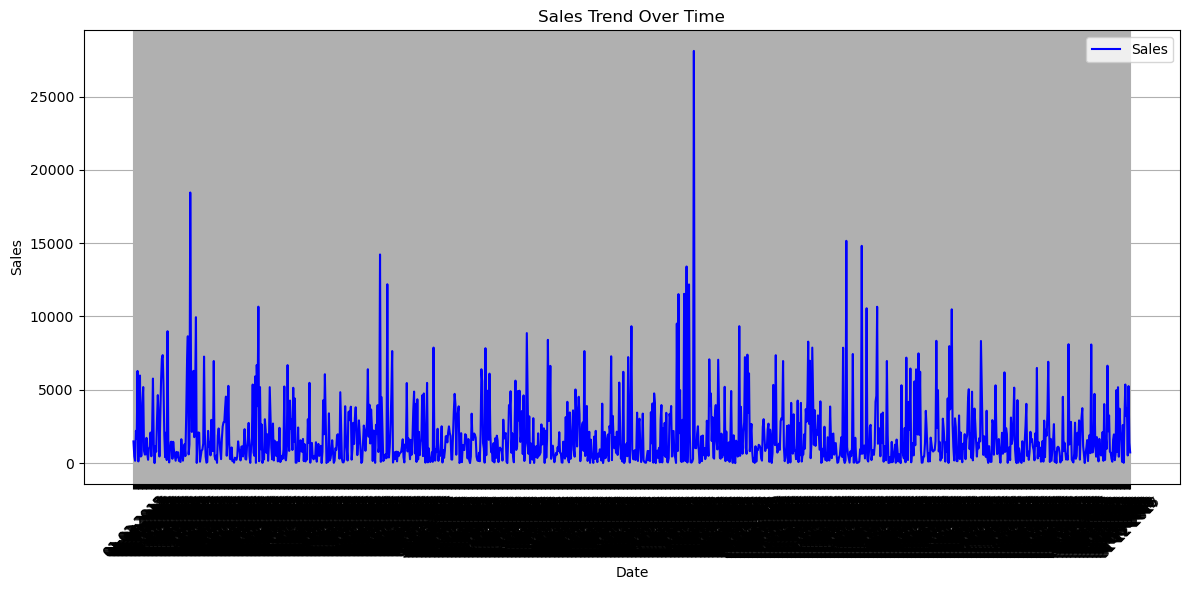

In [57]:
#data Preprocessing and Visualisation
#pd.to_datetime: Converts the "Order Date" column into datetime format allowing us to perform time-based operations.
groupby: #Groups the data by "OrderDate" and sums the sales for each date, 
                           # creating a time series of daily sales.


    



sales_by_date = data.groupby('Order Date')['Sales'].sum().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(sales_by_date['Order Date'], sales_by_date['Sales'], label='Sales', color='blue')
plt.title('Sales Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



In [41]:
#creating lagged features

#create_lagged_features: This function generates lagged features by shifting the sales data by a given number of time steps like 1, 2, 3, etc. Lag features help the model learn from the previous sales data to predict future sales.
#dropna: Drops rows with missing values which are introduced due to the shift operation when lagging.
def create_lagged_features(data, lag=1):
    lagged_data = data.copy()
    for i in range(1, lag+1):
        lagged_data[f'lag_{i}'] = lagged_data['Sales'].shift(i)
    return lagged_data

lag = 5  
sales_with_lags = create_lagged_features(data[['Order Date', 'Sales']], lag)

sales_with_lags = sales_with_lags.dropna()

In [45]:
#preparing data for training

#drop(columns): Removes the 'Order Date' and 'Sales' columns from the feature set X since they are not needed for training as sales is the target variable.
#train_test_split: Splits the dataset into training (80%) and testing (20%) sets.
#shuffle=False: ensures that the data is split in chronological order preserving the time series structure.

X = sales_with_lags.drop(columns=['Order Date', 'Sales'])
y = sales_with_lags['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [47]:
#training the XGBoost Model


#Training the XGBoost Model

#Here we will train the XGBoost model. It is a machine learning algorithm that uses gradient boosting to create highly accurate predictive models particularly well-suited for regression tasks like sales forecasting.

#XGBRegressor: Initializes an XGBoost model for regression tasks.
#objective='reg:squarederror': indicates that we are solving a regression problem i.e predicting continuous sales values.
#learning_rate (lr): Controls the step size at each iteration while moving toward a minimum of the loss function with smaller values leading to slower convergence.
#n_estimators: The number of boosting rounds or trees to build with higher values improving model accuracy but potentially leading to overfitting.
#max_depth: Defines the maximum depth of each decision tree controlling the complexity of the model. Deeper trees can model more complex patterns.
#fit: Trains the model on the training data (X_train, y_train).


model_xgb = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, max_depth=5)
model_xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [53]:
#making predictions and evaluating the model

#we make predictions and evaluate the model performance using RMSE.

#predict: Makes predictions on the test set (X_test) using the trained XGBoost model.
#mean_squared_error: Computes the Mean Squared Error (MSE) between actual and predicted values. We use np.sqrt to compute the Root Mean Squared Error (RMSE), which is a standard metric for evaluating regression models.

predictions_xgb = model_xgb.predict(X_test)
rmse_xgb = np.sqrt(mean_squared_error(y_test, predictions_xgb))

print(f"RMSE: {rmse_xgb:.2f}")


#The RMSE of 734.63 indicates the average deviation between the actual and predicted sales values. A lower RMSE value signifies better model accuracy, with the model's predictions being closer to the actual sales data. As we have large amount of sales data this RMSE score is accptable.

RMSE: 734.63


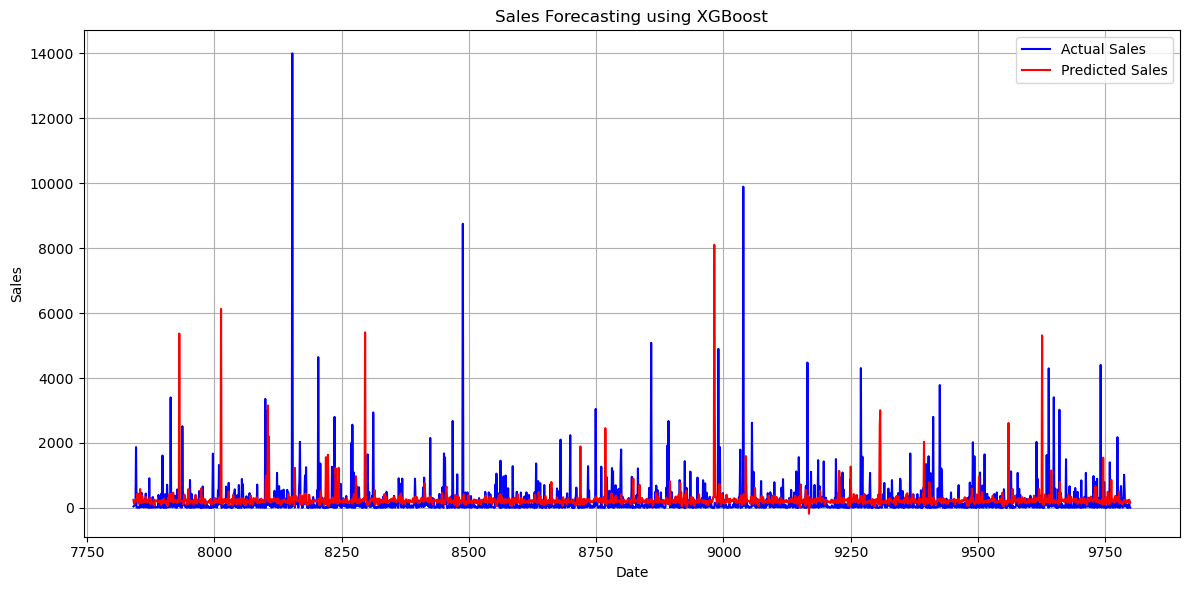

In [61]:
#visualizing results

#We will plot both the actual and predicted sales to visually compare the performance of the model.



plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Actual Sales', color='blue')
plt.plot(y_test.index, predictions_xgb, label='Predicted Sales', color='red')
plt.title('Sales Forecasting using XGBoost')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
#As we can see the predicted and actual values are quite close to each other this proves the efficiency of our model. Sales forecasting using machine learning models like XGBoost can significantly enhance the accuracy of predictions by capturing temporal patterns in historical data. It can be used for improving sales predictions helping businesses optimize inventory, pricing and demand planning.